# $\Psi(2S)$ discovery with CMS data
#### Gabriele Radano, Matteo Bellino - Spring semester 2025

# 0. Importing packages

In [1]:
# Importing packages
import pickle as pkl                 # Needed to import the pkl files
import numpy  as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from dataclasses import dataclass
from scipy.integrate import quad     # Numerical integral evaluation, useful to compute the integral of the model inside the bin
import sys                           # Needed to know what's the highest float value accepted

# 1. Loading data

In [2]:
# Importing data from files
with open('DataSet.pkl', 'rb') as file: # The 'rb' stands for 'read binary', necessary for this kind of file
    data_HS = pkl.load(file)            # Data with High Statistics 
    
with open('DataSet_lowstat.pkl', 'rb') as file:
    data_LS = pkl.load(file)            # Data with Low Statistics

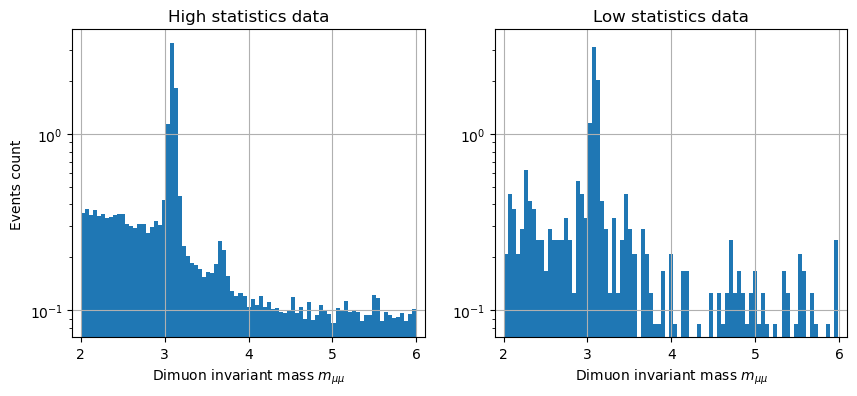

In [3]:
# Plotting raw data
normalize = True
scale     = 'log'
bin_num   = int(np.sqrt(len(data_HS))/2)

fig, axes = plt.subplots(1,2, figsize=(10,4))

ax = axes[0]
ax.grid(1)
ax.hist(data_HS, density=normalize, bins=bin_num)
ax.set_title('High statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_yscale(scale)
ylim = ax.set_ylim()

ax = axes[1]
ax.grid(1)
ax.hist(data_LS, density=normalize, bins=bin_num)
ax.set_title('Low statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
#ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_ylim(ylim)
ax.set_yscale(scale)
plt.show()

# 2. Defining the model

## 2.1. Bare background

Following the instructions of the README file, we will model the bare background (and with that I mean without the
peak of the J/$\Psi$ resonance) with Chebychev polynomial of order three. 
Being honest, they are not super clear about what this is so I had to dig inside the CERN definitions of tools they use to fit.
[There](https://root.cern/doc/master/ChebyshevPol_8h_source.html), at line 66, we see how the third order Chebyshev polynomial is evaluated.
Apparently, it returns
\begin{equation}
    c_3 \cdot (4x^3-3x) + c_2\cdot(2x^2 - 1) + c_1\cdot x + c_0
\end{equation}
but this has four parameters! However we shall factor in also the normalization condition: its integral between 2 and 6 must equal one. With this constraint, the most general polynomial of order 3 is
\begin{equation}
    ax^3+bx^2+cx+\left(\frac{1}{4}-4c-\frac{52}{3}b-80a\right)
\end{equation}


In [10]:
def cheb3(x, params):
    a1, a2, a3 = params
    return a3*(4*x**3-3*x) + a2*(2*x**2-1) + a1*x

In [11]:
def poly3(x, params):
    '''A generic polynomial of order 3 normalized between 2 and 6.

    It needs three parameters, (a,b,c), the coefficients of the polynomial 
                ax^3+bx^2+cx+fixed_by_normalization
    where the term of order 0 is fixed by the normalization condition.'''
    a,b,c = params
    value = a*x**3 + b*x**2 + c*x + (1/4-4*c-52*b/3-80*a) 
    return value

In [12]:
def get_binned_model(model, params, bin_edges):
    '''Numerical integral of the model

    This function returns the integral of the given model, integrated inside each bin, so that it can be
    compared with the binned data. It requires the parameters of the model which must be normalized be-
    tween 2 and 6; the n+1 edges of the n bins used to bin the data. It returns an array with n entries
    (one per bin) containing the integral of poly3 evaluated in that bin.'''

    integrand = lambda x: model(x, params)

    binned_model = [] # The array that will contain the integrals of the poly3 model inside each bin
    for i, lower_extreme in enumerate(bin_edges):
        if i == len(bin_edges)-1:
            pass
        else:
            upper_extreme = bin_edges[i+1]
            integral, _ = quad(integrand, lower_extreme, upper_extreme)
            binned_model.append(integral)
            
    return np.array(binned_model)

In [13]:
@dataclass
class get_bNLL(): # Function to evaluate the binned Negative Log Likelihood
    data:       np.array
    bin_number: int
    model:      callable # Not the model but a function that evaluates its integral inside each bin. It
                         # the model parameters and the edges of the bin (n+1 edges for n bins)

    def __post_init__(self):
        self.binned_data, self.bin_edges = np.histogram(self.data, bins=self.bin_number, density=False)

    def __call__(self, params):
        '''Evaluates the binned Negative Log Likelihood

        This function only requires the parameters of the model being used
        It is the callable function of the class get_bNLL which already has the binned data, the bin edges 
        and the model we are comparing the data to.
        We assume that the number of points inside each bin follows a Poisson distribution: the parameter
        lambda (the expectation value of events inside each bin) is the model's integral over the same bin.'''

        N_model = len(self.data) # THIS IS JUST FOR TESTING <---------------------------------------------------------------------------
        binned_model = get_binned_model(self.model, params, self.bin_edges) * N_model

        x = np.linspace(2,6, 10000) # To ensure we don't consider models with negative values <-----------------------------------------
        if any(self.model(x,params)<0):
            bNLL = sys.float_info.max # This is the highest possible float supported by the computer
        else:
            bNLL = sum( binned_model - self.binned_data*np.log(binned_model) )

        return bNLL    

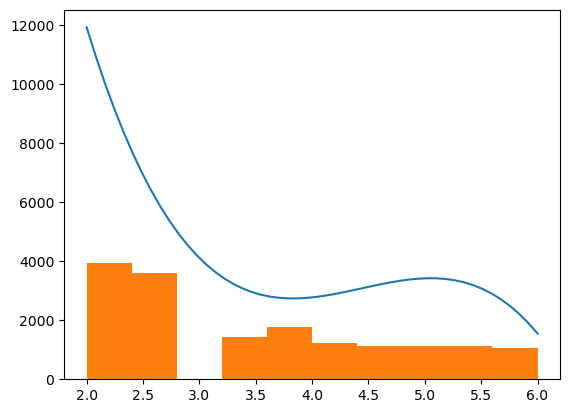

In [16]:
bNLL_HS_poly3 = get_bNLL(data=data_HS[(data_HS<2.8) | (data_HS>3.3)],
                         bin_number=10,
                         model=poly3)
initial_params = [0,0,0]
optimization_results = minimize(bNLL_HS_poly3, initial_params)

optimized_params = optimization_results.x
x = np.linspace(2,6)
y = poly3(x, optimized_params) * len(data_HS[(data_HS<2.8) | (data_HS>3.3)])
plt.plot(x,y)
plt.hist(data_HS[(data_HS<2.8) | (data_HS>3.3)], bins=10)
plt.show()